In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt,hilbert
from scipy.stats import pearsonr,wilcoxon,mannwhitneyu,kruskal,linregress
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore



params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)
def format_ax(ax,xlim,ylim,xspace,yspace):
   
    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))

In [95]:
  def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 

In [41]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [42]:
###low pass filter pupil
def filter_pupil(pupil,order = 1,cutoff = 1,fs = 20):
    def butter_lowpass(cutoff, fs, order=5):
        return butter(order, cutoff, fs=fs, btype='low', analog=False)

    def butter_lowpass_filter(data, cutoff, fs, order=5):
        b, a = butter_lowpass(cutoff, fs, order=order)
        y = lfilter(b, a, data)
        return y

    return butter_lowpass_filter(pupil, cutoff, fs, order)

In [43]:
###low pass filter face
def filter_face(face,order = 1,cutoff = 0.1,fs = 20):
    def butter_lowpass(cutoff, fs, order=5):
        return butter(order, cutoff, fs=fs, btype='low', analog=False)

    def butter_lowpass_filter(data, cutoff, fs, order=5):
        b, a = butter_lowpass(cutoff, fs, order=order)
        y = lfilter(b, a, data)
        return y
    return butter_lowpass_filter(face, cutoff, fs, order)

In [44]:
### Function to get LC facial movement

def get_LCface_events(id,date):
    id = id
    date = date
    path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
    df = pd.read_csv(path)
    time = df["t"]
    pupil = np.array(zscore(df["pupil"])) ###zscore pupil data
    face = np.array(zscore(df["mot_whisk"]))
    ###Onset detection alogrithm
    filter = filter_face(face) ###first apply low pass filter to face trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]


    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
            if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
                offset = start + np.argmin(filter[start:end])
            else:
                offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last pupil event
    start = region_ix[-1][-1]
    end = len(pupil)
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get pupil event amplitudes
    amplitudes = []
    amplitudes_ix = []
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(face[on:off]))

    ###get pupil event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)


    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    #"mean_dff" : mean_dffs,
    }
    return pd.DataFrame.from_dict(events_dict)


In [45]:
### Function to get LC pupil dilation evens

def get_LCpupil_events(id,date):
    id = id
    date = date
    path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
    df = pd.read_csv(path)
    time = df["t"]
    pupil = np.array(zscore(df["pupil"])) ###zscore pupil data

    ###Onset detection alogrithm
    filter = filter_pupil(pupil) ###first apply low pass filter to pupil trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]


    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
        if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
            offset = start + np.argmin(filter[start:end])
        else:
            offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last pupil event
    start = region_ix[-1][-1]
    end = len(pupil)
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get pupil event amplitudes
    amplitudes = []
    amplitudes_ix = []
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(filter[on:off]))

    ###get pupil event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)


    ###create dictionary

    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    }

    return pd.DataFrame.from_dict(events_dict)

In [46]:
### Function to get ACC facial movement aligned events

def get_ACCface_events(id,date):
    id = id
    date = date
    #face_path = f"/Users/nithik/Library/CloudStorage/Box-Box/HUDA_LAB_DATA/ethanol_data/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
    #path = f"/Users/nithik/Library/CloudStorage/Box-Box/HUDA_LAB_DATA/ethanol_data/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
    face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
    path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
    df = pd.read_csv(path)
    pupil = np.array(df["Pupil Size"])
    time = np.array(df["Time"])
    speed = np.array(df["Running Speed"])
    speed[0] = 0
    dff = np.array(df["dFF"])
    face = np.array(pd.read_csv(face_path)["Facial Movement"])

    ###Onset detection alogrithm

    
    filter = filter_face(face) ###first apply low pass filter to face trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]


    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
        if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
            offset = start + np.argmin(filter[start:end])
        else:
            offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last face event
    start = region_ix[-1][-1]
    end = 36000
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get face event amplitudes
    amplitudes = []
    amplitudes_ix = []
    ###change to align to raw peak
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(face[on:off]))


    ###get face event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)

    ###get dff data
    aucs = []
    peak_dffs = []
    mean_dffs = []
    for onset,offset in zip(onsets_ix,offset_ix):
        baseline = np.mean(dff[onset-40:onset-10])
        peak_dffs.append(max(dff[onset:offset]) - np.mean(dff[onset-30:onset]))
        mean_dffs.append(np.mean(dff[onset:offset])- np.mean(dff[onset-20:onset]))

    ###create dictionary

    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    "peak_dff" : peak_dffs,
    "mean_dff" : mean_dffs,
    }
    return pd.DataFrame.from_dict(events_dict)


In [47]:
### Function to get ACC pupil dilation events

def get_ACCpupil_events(id,date):
    id = id
    date = date
    face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
    path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
    df = pd.read_csv(path)
    pupil = np.array(df["Pupil Size"])
    time = np.array(df["Time"])
    speed = np.array(df["Running Speed"])
    speed[0] = 0
    dff = np.array(df["dFF"])
    face = np.array(pd.read_csv(face_path)["Facial Movement"])

    ###Onset detection alogrithm

    filter = filter_pupil(pupil) ###first apply low pass filter to pupil trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]

    ##join regions that are near eachother again
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
        if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
            offset = start + np.argmin(filter[start:end])
        else:
            offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last pupil event
    start = region_ix[-1][-1]
    end = 36000
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get pupil event amplitudes
    amplitudes = []
    amplitudes_ix = []
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(filter[on:off]))

    ###get pupil event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)

    ###get dff data
    aucs = []
    peak_dffs = []
    mean_dffs = []
    for onset,offset in zip(onsets_ix,offset_ix):
        peak_dffs.append(max(dff[onset:offset]) - np.mean(dff[onset-30:onset]))
        aucs.append(np.trapz(dff[onset:offset]))
        mean_dffs.append(np.mean(dff[onset:offset])- np.mean(dff[onset-20:onset]))

    ###create dictionary

    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    "peak_dff" : peak_dffs,
    "aucs" : aucs,
    "mean_dff" : mean_dffs,


    }
    

    return pd.DataFrame.from_dict(events_dict)


In [48]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [49]:
### Get data for Fig8A (Left)

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_ACCpupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        onsets_ix = events["onsets"]
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = filter_pupil(np.array(df["Pupil Size"]))
        time = np.array(df["Time"])
        speed = zscore(np.array(df["Running Speed"]))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        onsets = [time[on] for on in events["onsets"]]


        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 2, post = 10 )
        trial_matrix,trial_times = trial_align(onsets,time,dff,fps = 20,pre = 2, post = 10)
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 2, post = 10)

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(pupil[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline

            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date}
                df_list.append(new_dict)

        for j,trial in enumerate(trial_matrix):
            baseline = np.mean(dff[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
         
            for i,Time in enumerate(trial_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date}
                df_list.append(new_dict)

        for j,trial in enumerate(face_matrix):
            baseline = np.mean(face[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
          
            for i,Time in enumerate(face_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Face","ID" : id, "Date": date}
                df_list.append(new_dict)

ACCpupil_align_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/1870794281.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = ACCpupil_align_df.groupby(["ID","Time from Onset (s)","type"]).mean().reset_index(), x = "Time from Onset (s)", y = "value", hue = "type",errorbar = "se",palette= ["purple","dodgerblue","green"],legend= None,linewidth = 1)


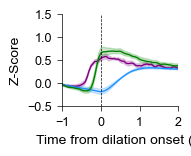

In [50]:
### Plot Fig8A (Left)
plt.figure(figsize = (1.5,1.2))
ax = sns.lineplot(data = ACCpupil_align_df.groupby(["ID","Time from Onset (s)","type"]).mean().reset_index(), x = "Time from Onset (s)", y = "value", hue = "type",errorbar = "se",palette= ["purple","dodgerblue","green"],legend= None,linewidth = 1)
format_ax(ax,(-1,2),(-0.5,1.5),1,0.5)
ax.set_xlabel("Time from dilation onset (s)")
ax.set_ylabel('Z-Score')
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)

In [51]:
### Get data for Fig8A (Right)

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_LCpupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        onsets_ix = events["onsets"]
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = [1,2,3,4]))
   
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = filter_pupil(np.array(zscore(df["pupil"]))) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        onsets = [time[on] for on in events["onsets"]]


       

        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 10, post = 10 )
        

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(pupil[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

        trial_matrix,trial_times = trial_align(onsets,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(trial_matrix):
            baseline = np.mean(dff[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(trial_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)
        
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(face_matrix):
            baseline = np.mean(face[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(face_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "face","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)


LCpupil_align_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/3862569458.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = LCpupil_align_df.groupby(["ID","Time from Onset (s)","type"]).mean().reset_index(), x = "Time from Onset (s)", y = "value", hue = "type",errorbar = "se",palette= ["dodgerblue","green","purple"],legend= None,linewidth = 1)


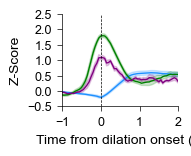

In [52]:
### Plot Fig8A (Right)
plt.figure(figsize = (1.5,1.2))
ax = sns.lineplot(data = LCpupil_align_df.groupby(["ID","Time from Onset (s)","type"]).mean().reset_index(), x = "Time from Onset (s)", y = "value", hue = "type",errorbar = "se",palette= ["dodgerblue","green","purple"],legend= None,linewidth = 1)
format_ax(ax,(-1,2),(-0.5,2.5),1,0.5)
ax.set_xlabel("Time from dilation onset (s)")
ax.set_ylabel('Z-Score')
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)

In [53]:
### Get data for Fig 8B (Left)

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_ACCface_events(id,date)
        onsets_ix = events["onsets"]
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = [1,2,3,4]))
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        onsets = [time[on] for on in events["onsets"]]
        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 10, post = 10 )

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(pupil[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

        trial_matrix,trial_times = trial_align(onsets,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(trial_matrix):
            baseline = np.mean(dff[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(trial_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)
        
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(face_matrix):
            baseline = np.mean(face[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(face_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "face","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

ACCface_align_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/4276485839.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = ACCface_align_df.groupby(["ID","Time from Onset (s)","type"]).mean().reset_index(), x = "Time from Onset (s)", y = "value", hue = "type",errorbar = "se",palette= ["dodgerblue","green","purple"],legend= None,linewidth = 1)


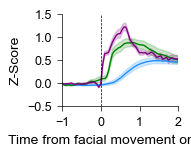

In [54]:
### Plot Fig8B (Left)
plt.figure(figsize = (1.5,1.2))
ax = sns.lineplot(data = ACCface_align_df.groupby(["ID","Time from Onset (s)","type"]).mean().reset_index(), x = "Time from Onset (s)", y = "value", hue = "type",errorbar = "se",palette= ["dodgerblue","green","purple"],legend= None,linewidth = 1)
format_ax(ax,(-1,2),(-0.5,1.5),1,0.5)
ax.set_xlabel("Time from facial movement onset (s)")
ax.set_ylabel('Z-Score')
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)

In [55]:
### Get data for Fig8B (Right)

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],



}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_LCface_events(id,date)
        onsets_ix = events["onsets"]
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = [1,2,3,4]))
   
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        pupil = filter_pupil(zscore(np.array(df["pupil"])))
        time = df["t"]
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        face = zscore(np.array(df["mot_whisk"]))
        onsets = [time[on_ix] for on_ix in events["onsets"]]
        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 10, post = 10 )

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(pupil[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

        trial_matrix,trial_times = trial_align(onsets,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(trial_matrix):
            baseline = np.mean(dff[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(trial_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)
        
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(face_matrix):
            baseline = np.mean(face[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(face_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "face","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

LCface_align_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/909310658.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = LCface_align_df.groupby(["ID","Time from Onset (s)","type"]).mean().reset_index(), x = "Time from Onset (s)", y = "value", hue = "type",errorbar = "se",palette= ["dodgerblue","green","purple"],legend= None,linewidth = 1)


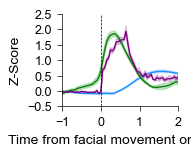

In [56]:
### Plot Fig8B (Right)
plt.figure(figsize = (1.5,1.2))
ax = sns.lineplot(data = LCface_align_df.groupby(["ID","Time from Onset (s)","type"]).mean().reset_index(), x = "Time from Onset (s)", y = "value", hue = "type",errorbar = "se",palette= ["dodgerblue","green","purple"],legend= None,linewidth = 1)
format_ax(ax,(-1,2),(-0.5,2.5),1,0.5)
ax.set_xlabel("Time from facial movement onset (s)")
ax.set_ylabel('Z-Score')
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)

In [90]:
### Get LC data for Fig8C
pre = 1
post = 0.5


id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
graph_df_list = []
for id,dates in id_date.items():
    mousedil_matrix = []
    mouseface_matrix = []
    mousedff_matrix = []
    for date in dates:
      
        events = get_ACCpupil_events(id,date)
        amplitudes = events["amplitudes"]

        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = np.array(df["Running Speed"])
        speed = zscore(speed)
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        onsets = [time[on] for on in events["onsets"]]

        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = pre, post = post)
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = pre, post = post)
        dff_matrix,dff_times = trial_align(onsets,time,dff,fps = 20,pre = pre, post = post)
        mousedil_matrix.extend(dil_matrix)
        mouseface_matrix.extend(face_matrix)
        mousedff_matrix.extend(dff_matrix)
    
    corr = correlate(np.mean(mousedil_matrix,axis=0), np.mean(mousedff_matrix,axis = 0))
    lags = correlation_lags(len(np.mean(mousedil_matrix,axis=0)), len(np.mean(mousedff_matrix,axis = 0)))
    lags = lags/20
    corr /= np.max(corr)
    i = np.argmax(corr)
    delay = lags[i]
    lag_dict = {"Cross-Correlation Delay (s)" : delay,"ID": id,"type":"P-D","Region":"ACC"}
    df_list.append(lag_dict)

    corr = correlate(np.mean(mouseface_matrix,axis=0), np.mean(mousedff_matrix,axis = 0))
    lags = correlation_lags(len(np.mean(mouseface_matrix,axis=0)), len(np.mean(mousedff_matrix,axis = 0)))
    lags = lags/20
    corr /= np.max(corr)
    i = np.argmax(corr)
    delay = lags[i]
    lag_dict = {"Cross-Correlation Delay (s)" : delay,"ID": id,"type":"F-D","Region":"ACC"}
    df_list.append(lag_dict)
 
acc_lag_df = pd.DataFrame.from_dict(df_list)


In [91]:
### Get LC data for Fig8C

pre = 1
post = 0.5

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],
}
df_list = []
graph_df_list = []
for id,dates in id_date.items():
    mousedil_matrix = []
    mouseface_matrix = []
    mousedff_matrix = []
    for date in dates:
      
        events = get_LCpupil_events(id,date)
        amplitudes = events["amplitudes"]

        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = np.array(zscore(df["pupil"])) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        onsets = [time[on] for on in events["onsets"]]

        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = pre, post = post)
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = pre, post = post)
        dff_matrix,dff_times = trial_align(onsets,time,dff,fps = 20,pre = pre, post = post)
        mousedil_matrix.extend(dil_matrix)
        mouseface_matrix.extend(face_matrix)
        mousedff_matrix.extend(dff_matrix)


    
    corr = correlate(np.mean(mousedil_matrix,axis=0), np.mean(mousedff_matrix,axis = 0))
    lags = correlation_lags(len(np.mean(mousedil_matrix,axis=0)), len(np.mean(mousedff_matrix,axis = 0)))
    lags = lags/20
    corr /= np.max(corr)
    i = np.argmax(corr)
    delay = lags[i]
    lag_dict = {"Cross-Correlation Delay (s)" : delay,"ID": id,"type":"P-D","Region":"LC"}
    df_list.append(lag_dict)

    corr = correlate(np.mean(mouseface_matrix,axis=0), np.mean(mousedff_matrix,axis = 0))
    lags = correlation_lags(len(np.mean(mouseface_matrix,axis=0)), len(np.mean(mousedff_matrix,axis = 0)))
    lags = lags/20
    corr /= np.max(corr)
    i = np.argmax(corr)
    delay = lags[i]
    lag_dict = {"Cross-Correlation Delay (s)" : delay,"ID": id,"type":"F-D","Region":"LC"}
    df_list.append(lag_dict)
      
        
lc_lag_df = pd.DataFrame.from_dict(df_list)


In [92]:
### Combine into one df for Fig8C
lag_df = pd.concat([lc_lag_df,acc_lag_df])

Text(0, 0.5, 'P-D x-corr delay (s)')

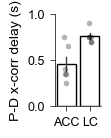

In [93]:
### Plot Fig8C (Left)
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = lag_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'P-D'"), x = "Region", y = "Cross-Correlation Delay (s)",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = lag_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'P-D'"), x = "Region", y = "Cross-Correlation Delay (s)",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(0,1.5,0.5))
g.set(ylim=(0, 1))
g.set_ylabel("P-D x-corr delay (s)")

Text(0, 0.5, 'F-D x-corr delay (s)')

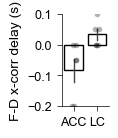

In [94]:
### Plot Fig8C (Right)
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = lag_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'F-D'"), x = "Region", y = "Cross-Correlation Delay (s)",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = lag_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'F-D'"), x = "Region", y = "Cross-Correlation Delay (s)",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-0.3,0.3,0.1))
g.set(ylim=(-0.2, 0.1))
g.set_ylabel("F-D x-corr delay (s)")


In [ ]:
### Get ACC data for Fig8D, 8E

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    mousedil_matrix = []
    mouseface_matrix = []
    mousedff_matrix = []
    for date in dates:

        events = get_ACCpupil_events(id,date)
        #onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        onsets_ix = events["onsets"]
  
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore(np.array(df["Running Speed"]))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        onsets = [time[on] for on in onsets_ix]

        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 2, post = 10 )
        trial_matrix,trial_times = trial_align(onsets,time,dff,fps = 20,pre = 2, post = 10)
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 2, post = 10)
        mousedil_matrix.extend(dil_matrix)
        mouseface_matrix.extend(face_matrix)
        mousedff_matrix.extend(trial_matrix)

    dff_trial = np.mean(mousedff_matrix,0)
    dff_trial = dff_trial - np.min(dff_trial)
    max_ix = np.argmax(dff_trial)
    min_ix = np.argmin(dff_trial)
    peak_dff =  np.max(dff_trial)
    target = peak_dff/2
    t50_ix = np.where(dff_trial[min_ix:] > target)[0][0] + min_ix
    t50 = (t50_ix - 40)/20 ###relative to dilation onset

    ###find onset of dff by finding continuous region from min to max

    regions = list(groupSequence(dff_trial[min_ix:max_ix]))
    corrected_regions = [region for region in regions if len(region) >=5 ]
    first_region = corrected_regions[0]
    region_ix = [np.where(dff_trial[min_ix:max_ix] == val)[0][0] + min_ix for val in first_region]
    
    onset_ix,offset_ix = region_ix[0],region_ix[-1]
    onset_time = (onset_ix-40)/20
            
    new_dict = {"ID" : id,"T50 (s)": t50,"Region":"ACC","Onset":onset_time}
    df_list.append(new_dict)
      
acc_t50_df = pd.DataFrame.from_dict(df_list)


In [ ]:
### Get LC data for Fig8D, 8E

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],
}

df_list = []
for id,dates in id_date.items():
    mousedil_matrix = []
    mouseface_matrix = []
    mousedff_matrix = []
    for date in dates:
      
        events = get_LCpupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        onsets_ix = events["onsets"]
  
       
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = np.array(zscore(df["pupil"])) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data

        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 2, post = 10 )
        trial_matrix,trial_times = trial_align(onsets,time,dff,fps = 20,pre = 2, post = 10)
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 2, post = 10)
        mousedil_matrix.extend(dil_matrix)
        mouseface_matrix.extend(face_matrix)
        mousedff_matrix.extend(trial_matrix)

    dff_trial = np.nanmean(mousedff_matrix,0)
    dff_trial = dff_trial - np.min(dff_trial)
    max_ix = np.argmax(dff_trial)
    min_ix = np.argmin(dff_trial)
    peak_dff =  np.max(dff_trial)
    target = peak_dff/2
    t50_ix = np.where(dff_trial[min_ix:] > target)[0][0] + min_ix
    t50 = (t50_ix - 40)/20 ###relative to dilation onset
    
    ###find onset of dff by finding continuous region from min to max

    regions = list(groupSequence(dff_trial[min_ix:max_ix]))
    corrected_regions = [region for region in regions if len(region) >=5 ]
    first_region = corrected_regions[0]
    region_ix = [np.where(dff_trial[min_ix:max_ix] == val)[0][0] + min_ix for val in first_region]
    
    onset_ix,offset_ix = region_ix[0],region_ix[-1]
    onset_time = (onset_ix-40)/20





            
    new_dict = {"ID" : id, "Date": date,"T50 (s)": t50,"Region":"LC","Onset":onset_time}
    df_list.append(new_dict)


      
lc_t50_df = pd.DataFrame.from_dict(df_list)
t50_df = pd.concat([lc_t50_df,acc_t50_df])

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/3409980033.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = t50_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Onset",errorbar="se",fill = None,errwidth= 1,order =["ACC","LC"] )
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/3409980033.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = t50_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Onset",color = "black",alpha = 0.3,s = 4,jitter = 0.1,order = ["ACC","LC"])
/var/folders/hs/_xmn26cn3qd

MannwhitneyuResult(statistic=0.0, pvalue=0.004479258891846413)

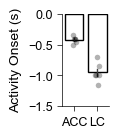

In [ ]:
### Plot Fig8D
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = t50_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Onset",errorbar="se",fill = None,errwidth= 1,order =["ACC","LC"] )
sns.stripplot(data = t50_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Onset",color = "black",alpha = 0.3,s = 4,jitter = 0.1,order = ["ACC","LC"])
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-1.5,0.5,.5))
g.set(ylim=(-1.5, 0))
g.set_ylabel("Activity Onset (s)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/3338205868.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = t50_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "T50 (s)",errorbar="se",fill = None,errwidth= 1,order = ["ACC","LC"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/3338205868.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = t50_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "T50 (s)",color = "black",alpha = 0.3,s = 4,jitter = 0.1,order = ["ACC","LC"])
/var/folders/hs/_xmn26c

MannwhitneyuResult(statistic=0.0, pvalue=0.00455141587451369)

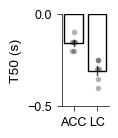

In [ ]:
### Plot Fig8D
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = t50_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "T50 (s)",errorbar="se",fill = None,errwidth= 1,order = ["ACC","LC"])
sns.stripplot(data = t50_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "T50 (s)",color = "black",alpha = 0.3,s = 4,jitter = 0.1,order = ["ACC","LC"])
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-0.5,0.5,.5))
g.set(ylim=(-0.5, 0))
g.set_ylabel("T50 (s)")

In [101]:
### Get ACC data for Fig8F, 8G


id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}


df_list = []
for id,dates in id_date.items():
    for date in dates:
       
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore(np.array(df["Running Speed"]))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        
        df = pd.DataFrame(pupil)
        df = df.rename(columns= {0:"pupil"})
        df["dff"] = dff
        df["face"] = face
        phases = np.angle(hilbert(df["pupil"]))
        df["phase_bin"] = pd.cut(phases,128,labels = False)
        df["ID"] = id
        df["Date"] = date
        df["Region"] = "ACC"
        df_list.append(df)
        
acc_hilbert_df = pd.concat(df_list)


In [102]:
### Get LC data for Fig8F, 8G


id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],
}


df_list = []
for id,dates in id_date.items():
    for date in dates:
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = np.array(zscore(df["pupil"])) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data

        df = pd.DataFrame(pupil)
        df = df.rename(columns= {0:"pupil"})
        df["dff"] = dff
        df["face"] = face
        phases = np.angle(hilbert(df["pupil"]))
        df["phase_bin"] = pd.cut(phases,128,labels = False)
        df["ID"] = id
        df["Date"] = date
        df["Region"] = "LC"

        df_list.append(df)
  
lc_hilbert_df = pd.concat(df_list)

              
hilbert_df = pd.concat([acc_hilbert_df,lc_hilbert_df])
###label hilbert_df
def label_trial(row):
    if 32<= row['phase_bin']<=64:
      return 'Dilating'
    elif 64< row['phase_bin']<=96:
      return "Constricting"
      
hilbert_df['Pupil_State'] = hilbert_df.apply(label_trial, axis=1)



/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/4167084997.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = hilbert_df.groupby(["ID","phase_bin","Region"]).mean().reset_index().query("Region == 'ACC'"), x = "phase_bin", y = "pupil", errorbar = "se",linewidth = 1,legend = None,color = "dodgerblue")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/4167084997.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = hilbert_df.groupby(["ID","phase_bin","Region"]).mean().reset_index().query("Region == 'ACC'"), x = "phase_bin", y = "df

[Text(0, 0, '-π'),
 Text(32, 0, '-π/2'),
 Text(64, 0, '0'),
 Text(96, 0, 'π/2'),
 Text(128, 0, 'π')]

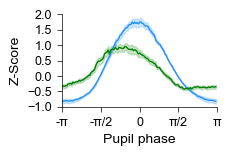

In [ ]:
### Plot Fig8F (Left)

plt.figure(figsize = (2,1.2))
ax = sns.lineplot(data = hilbert_df.groupby(["ID","phase_bin","Region"]).mean().reset_index().query("Region == 'ACC'"), x = "phase_bin", y = "pupil", errorbar = "se",linewidth = 1,legend = None,color = "dodgerblue")
ax = sns.lineplot(data = hilbert_df.groupby(["ID","phase_bin","Region"]).mean().reset_index().query("Region == 'ACC'"), x = "phase_bin", y = "dff", color = "green",errorbar = "se",linewidth = 1)

format_ax(ax,(0,128),(-1,2),32,0.5)
ax.set_xlabel("Pupil phase")
ax.set_ylabel('Z-Score')
labels = ["-π","-π/2","0","π/2","π"]
ax.set_xticklabels(labels)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/3354092839.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = hilbert_df.groupby(["ID","phase_bin","Region"]).mean().reset_index().query("Region == 'LC'"), x = "phase_bin", y = "pupil", color = "dodgerblue",errorbar = "se",linewidth = 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/3354092839.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = hilbert_df.groupby(["ID","phase_bin","Region"]).mean().reset_index().query("Region == 'LC'"), x = "phase_bin", y = "dff", color = "gre

[Text(0, 0, '-π'),
 Text(32, 0, '-π/2'),
 Text(64, 0, '0'),
 Text(96, 0, 'π/2'),
 Text(128, 0, 'π')]

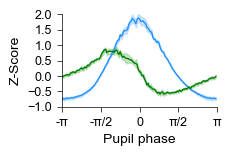

In [104]:
### Plot Fig8F (Right)

plt.figure(figsize = (2,1.2))
ax = sns.lineplot(data = hilbert_df.groupby(["ID","phase_bin","Region"]).mean().reset_index().query("Region == 'LC'"), x = "phase_bin", y = "pupil", color = "dodgerblue",errorbar = "se",linewidth = 1)
ax = sns.lineplot(data = hilbert_df.groupby(["ID","phase_bin","Region"]).mean().reset_index().query("Region == 'LC'"), x = "phase_bin", y = "dff", color = "green",errorbar = "se",linewidth = 1)

format_ax(ax,(0,128),(-1,2),32,0.5)
ax.set_xlabel("Pupil phase")
ax.set_ylabel('Z-Score')
ax.set_xticklabels(labels)

In [ ]:
### Plot Fig8G

plt.figure(figsize = (2,1.2))
ax = sns.lineplot(data = hilbert_df.groupby(["ID","phase_bin","Region"]).mean().reset_index(), x = "phase_bin", y = "dff", hue = "Region",errorbar = "se",linewidth = 1,legend = None,palette = ["deeppink","gold"])

format_ax(ax,(0,128),(-1,1.5),32,0.5)
ax.set_xlabel("Pupil phase")
ax.set_ylabel('∆ F/F')
ax.axvspan(32,64,alpha = 0.1,color = "red")
ax.axvspan(64,96,alpha = 0.1,color = "blue")
ax.set_xticklabels(labels)
plt.savefig(rf"/Users/nithik/Library/CloudStorage/Box-Box/HUDA_LAB_DATA/Manuscripts/2023-ACCArousal-CurrentBiology/SavedGraphs/LCvsACC_hilbert.pdf",format ="pdf",transparent = True,bbox_inches = "tight")


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/1381285728.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Dilating'"), x = "Region", y = "dff",errorbar="se",fill = None,errwidth= 1,edgecolor = "red")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/1381285728.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Dilating'"), x = "Region", y = "df

Text(0, 0.5, '∆ F/F (z-scr)')

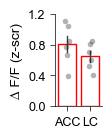

In [105]:
### Plot Fig8H (Left)
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Dilating'"), x = "Region", y = "dff",errorbar="se",fill = None,errwidth= 1,edgecolor = "red")
sns.stripplot(data = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Dilating'"), x = "Region", y = "dff",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(0,1.4,0.4))
g.set(ylim=(0, 1.2))
g.set_ylabel('∆ F/F (z-scr)')

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/4027759944.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Constricting'"), x = "Region", y = "dff",errorbar="se",fill = None,errwidth= 1,edgecolor = "blue")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/4027759944.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Constricting'"), x = "Region"

Text(0, 0.5, '∆ F/F (z-scr)')

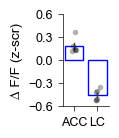

In [106]:
### Plot Fig8H (Right)
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Constricting'"), x = "Region", y = "dff",errorbar="se",fill = None,errwidth= 1,edgecolor = "blue")
sns.stripplot(data = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Constricting'"), x = "Region", y = "dff",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-0.6,1,0.3))
g.set(ylim=(-0.6, 0.6))
g.set_ylabel('∆ F/F (z-scr)')

In [109]:
### Get data for Fig8I

constrict_dff = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Constricting'").reset_index()["dff"]
dilate_dff = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Dilating'").reset_index()["dff"]
ratios = constrict_dff/dilate_dff
IDs = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Constricting'").reset_index()["ID"]
Regions = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Constricting'").reset_index()["Region"]
ratio_df = pd.DataFrame(IDs)
ratio_df = ratio_df.rename(columns= {0:"ID"})
ratio_df["Region"] = Regions
ratio_df["ratio"] = ratios

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/1800915153.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  constrict_dff = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Constricting'").reset_index()["dff"]
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/1800915153.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  dilate_dff = hilbert_df.groupby(["ID",'Pupil_State',"Region"]).mean().reset_index().query("Pupil_State == 'Dilating'").reset_index()["dff"]
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_5915/180091515

Text(0, 0.5, 'Ratio')

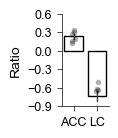

In [110]:
### Plot Fig8I
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = ratio_df, x = "Region", y = "ratio",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = ratio_df, x = "Region", y = "ratio",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-0.9,0.9,0.3))
g.set(ylim=(-0.9, 0.6))
g.set_ylabel('Ratio')